In [9]:
# This cell contains all the necessary imports for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [10]:
# Load the dataset
orders = pd.read_csv("dataset/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("dataset/raw/olist_order_items_dataset.csv")
customers = pd.read_csv("dataset/raw/olist_customers_dataset.csv")
reviews = pd.read_csv("dataset/raw/olist_order_reviews_dataset.csv")

In [11]:
df = pd.read_csv('dataset/processed/eda_df.csv')

###  Train-Test Split

In [12]:
# Create target variable
df["delivered_late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)
print(df[["order_estimated_delivery_date", "order_delivered_customer_date", "delivered_late"]].head())
print("Missing values in target:", df["delivered_late"].isna().sum())

  order_estimated_delivery_date order_delivered_customer_date  delivered_late
0                    2017-10-18           2017-10-10 21:25:13               0
1                    2018-08-13           2018-08-07 15:27:45               0
2                    2018-09-04           2018-08-17 18:06:29               0
3                    2017-12-15           2017-12-02 00:28:42               0
4                    2018-02-26           2018-02-16 18:17:02               0
Missing values in target: 0


In [13]:
# Separate features and target
X = df.drop(["delivered_late", "order_id", "customer_id", 
             "order_delivered_customer_date", "order_estimated_delivery_date"], axis=1,errors='ignore')
y = df["delivered_late"]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,     
    stratify=y           
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (79993, 13)
X_test : (19999, 13)


###  Data Preprocessing Pipeline

- Impute missing numeric values.

- Impute missing categorical values.

- Encode them to turn them into numbers.

- Outlier analysis

- Scale numeric features.

In [22]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

categoric_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categoric_cols)
    ],
    remainder='drop'
)

# Fit-transform
X_preprocessed = preprocessor.fit_transform(X)

In [24]:
# 1) review_score → mode
df["review_score"] = df["review_score"].fillna(df["review_score"].mode()[0])

# 2) delivery features → median
df["delivery_time_days"] = df["delivery_time_days"].fillna(df["delivery_time_days"].median())
df["carrier_delay_days"] = df["carrier_delay_days"].fillna(df["carrier_delay_days"].median())
df["delivery_diff_estimated_days"] = df["delivery_diff_estimated_days"].fillna(
    df["delivery_diff_estimated_days"].median()
)

# 3) price_freight_ratio → önce inf düzelt, sonra median
df["price_freight_ratio"] = df["price_freight_ratio"].replace([np.inf, -np.inf], np.nan)
df["price_freight_ratio"] = df["price_freight_ratio"].fillna(df["price_freight_ratio"].median())

# 4) Tarihler → NaT normal, ama ihtiyaç varsa "-1 day" olarak doldur
df["order_approved_at"] = df["order_approved_at"].fillna(pd.Timestamp("1970-01-01"))
df["order_delivered_carrier_date"] = df["order_delivered_carrier_date"].fillna(pd.Timestamp("1970-01-01"))
df["order_delivered_customer_date"] = df["order_delivered_customer_date"].fillna(pd.Timestamp("1970-01-01"))

In [25]:
df.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
price                            0
freight_value                    0
customer_city                    0
customer_state                   0
review_score                     0
delivered_late                   0
delivery_time_days               0
carrier_delay_days               0
delivery_diff_estimated_days     0
price_freight_ratio              0
dtype: int64

In [26]:
df["delivered_late"].value_counts()

delivered_late
0    91010
1     7819
Name: count, dtype: int64

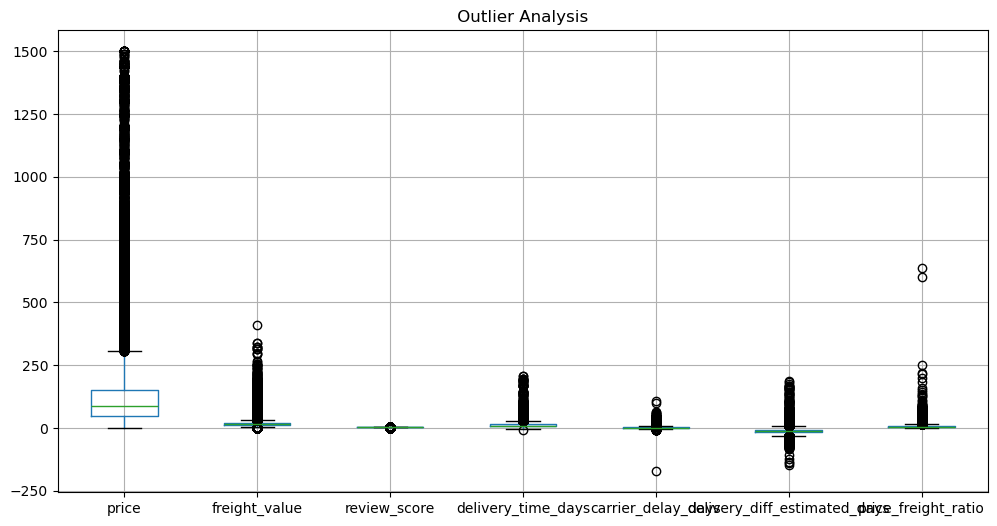

In [27]:
# Outlier Analysis for numeric columns
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title(" Outlier Analysis ")
plt.show()

###  Feature Selection

In [28]:
# Remove rows where price > 1500
df = df[df["price"] <= 1500]
print("Kalan satır sayısı / Remaining rows:", df.shape[0])

Kalan satır sayısı / Remaining rows: 98829


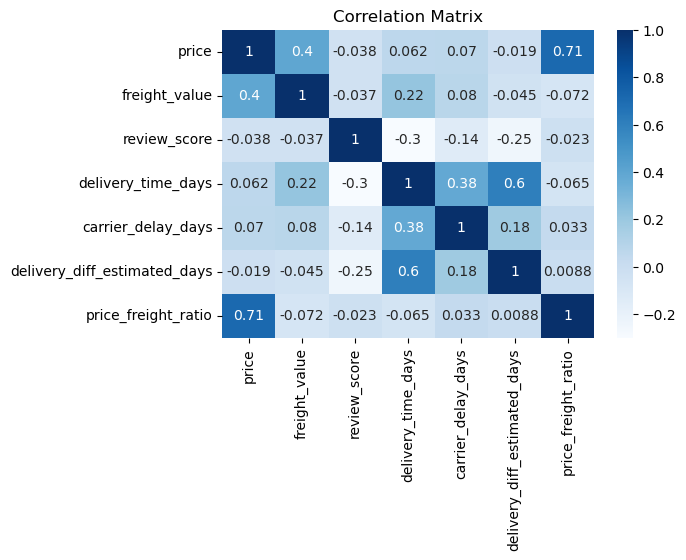

In [29]:
# Correlation Analysis
corr =df[numeric_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [30]:
# Low Variance Filter
# Remove features that have little to no variance

selector = VarianceThreshold(threshold=0.01)  
selector.fit(X.select_dtypes(include=[np.number]))
low_var_cols = X.select_dtypes(include=[np.number]).columns[~selector.get_support()]
print("\n Low Variance Columns:")
print(low_var_cols)


 Low Variance Columns:
Index([], dtype='object')


In [31]:
# Feature Importance
# Use a simple Random Forest to measure feature importance

feature_names = preprocessor.get_feature_names_out()

rf = RandomForestClassifier(random_state=42)
rf.fit(X_preprocessed, y)


feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importance (Top 10):")
print(feature_importance.head(10))


 Feature Importance (Top 10):
                                  Feature  Importance
5       num__delivery_diff_estimated_days    0.441683
3                 num__delivery_time_days    0.127590
2                       num__review_score    0.035817
4                 num__carrier_delay_days    0.012235
1                      num__freight_value    0.005196
6                num__price_freight_ratio    0.003835
0                              num__price    0.003676
10            cat__order_status_delivered    0.001644
274785             cat__customer_state_SP    0.001605
274778             cat__customer_state_RJ    0.001385


In [32]:
# Features after encoding
X_preprocessed.shape

(99992, 274787)

In [35]:
df.to_csv('dataset/processed/final_df.csv', index=False)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98829 entries, 0 to 99991
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98829 non-null  object 
 1   customer_id                    98829 non-null  object 
 2   order_status                   98829 non-null  object 
 3   order_purchase_timestamp       98829 non-null  object 
 4   order_approved_at              98829 non-null  object 
 5   order_delivered_carrier_date   98829 non-null  object 
 6   order_delivered_customer_date  98829 non-null  object 
 7   order_estimated_delivery_date  98829 non-null  object 
 8   price                          98829 non-null  float64
 9   freight_value                  98829 non-null  float64
 10  customer_city                  98829 non-null  object 
 11  customer_state                 98829 non-null  object 
 12  review_score                   98829 non-null  floa